# 06 — Modelado: Mask R-CNN

---
>  — Vision 06: Mask R-CNN**
>
> Este notebook implementa **Mask R-CNN** con backbone **ResNet-50 + FPN** (Feature Pyramid Network),
> preentrenado en COCO, fine-tuned para segmentación de instancias celulares.
>
> **Resultados finales (test set):**
> | Métrica | Valor | Interpretación |
> |---------|-------|----------------|
> | IoU | **0.202** | 🚨 Bajo |
> | Dice | **0.297** | 🚨 Bajo |
> | Precision | **0.855** | ✅ Las máscaras que predice son correctas |
> | Recall | **0.216** | 🚨 Detecta solo ~22 % de las células reales |
>
> **Patrón opuesto a HoVer-Net:** Mask R-CNN es **extremadamente conservador** —  
> cuando predice una célula, casi siempre tiene razón (Precision=0.855),  
> pero deja el 78 % de las células sin detectar.
>
> **¿Por qué tan bajo el Recall?**
> 1. **Imagen con 800 instancias celulares densas:**  
>    La RPN de Mask R-CNN fue diseñada para detectar objetos con separación clara.  
>    Con células superpuestas, las bounding boxes se solapan masivamente y el NMS  
>    (Non-Maximum Suppression) elimina la mayoría como duplicados.
> 2. **`detections_per_img=600`:** aunque se aumentó de los 100 por defecto a 600,  
>    imágenes con 800+ células siguen siendo un problema.
> 3. **`score_thresh=0.2`:** umbral de confianza relativamente alto. Bajar a 0.1  
>    aumentaría el recall a costa de más falsos positivos.


In [1]:
!pip install -q pycocotools torchmetrics

import os, sys, json, random, time
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as T
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torch.amp import GradScaler, autocast
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split, ParameterSampler

print(f'PyTorch     : {torch.__version__}')
print(f'Torchvision : {torchvision.__version__}')
print(f'CUDA        : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        g = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}: {g.name} — {g.total_memory/1e9:.1f} GB')
else:
    print('SIN GPU — activar T4x2 en Session options')

PyTorch     : 2.10.0+cu128
Torchvision : 0.25.0+cu128
CUDA        : True
  GPU 0: Tesla T4 — 15.6 GB
  GPU 1: Tesla T4 — 15.6 GB


In [2]:
# FIX #1: ruta correcta para Kaggle competitions
# /kaggle/input/sartorius-cell-instance-segmentation  (SIN 'competitions/')
DATA_DIR   = Path('/kaggle/input/competitions/sartorius-cell-instance-segmentation')
TRAIN_DIR  = DATA_DIR / 'train'
TRAIN_CSV  = DATA_DIR / 'train.csv'
OUTPUT_DIR = Path('/kaggle/working')

if not DATA_DIR.exists():
    raise RuntimeError(
        'Dataset no encontrado.\n'
        'Panel derecho -> + Add data -> sartorius-cell-instance-segmentation -> Add'
    )
print(f'Dataset OK: {len(list(TRAIN_DIR.glob("*.png")))} imagenes')

CFG = {
    'seed'        : 42,
    'img_size'    : 512,
    'val_split'   : 0.15,
    'num_classes' : 4,
    'score_thresh': 0.2,
    'nms_thresh'  : 0.3,
    'use_fp16'    : True,
    'n_search'    : 3,
    # FIX #4: checkpoint en CFG para que la celda de visualizacion lo encuentre
    'checkpoint'  : str(OUTPUT_DIR / 'maskrcnn_best.pth'),
}

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark     = True
    torch.backends.cudnn.deterministic = False

set_seed(CFG['seed'])
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_GPUS    = torch.cuda.device_count()
NUM_WORKERS = min(4, max(1, NUM_GPUS) * 2)
PIN_MEMORY  = torch.cuda.is_available()
USE_AMP     = torch.cuda.is_available() and CFG['use_fp16']

print(f'Device  : {DEVICE}')
print(f'GPUs    : {NUM_GPUS}')
print(f'AMP     : {USE_AMP} | workers: {NUM_WORKERS}')

Dataset OK: 606 imagenes
Device  : cuda
GPUs    : 2
AMP     : True | workers: 4


In [3]:
df = pd.read_csv(TRAIN_CSV)
print(f'Anotaciones : {len(df):,}')
print(f'Imagenes    : {df.id.nunique()}')
print(f'\nTipos celulares:')
print(df.groupby('cell_type')['id'].nunique())
df.head(3)

Anotaciones : 73,585
Imagenes    : 606

Tipos celulares:
cell_type
astro     131
cort      320
shsy5y    155
Name: id, dtype: int64


,id,annotation,width,height,cell_type,plate_time,sample_date,sample_id,elapsed_timedelta
0,0030fd0e6378,118145 6 118849 7 119553 8 120257 8 120961 9 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
1,0030fd0e6378,189036 1 189739 3 190441 6 191144 7 191848 8 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
2,0030fd0e6378,173567 3 174270 5 174974 5 175678 6 176382 7 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00


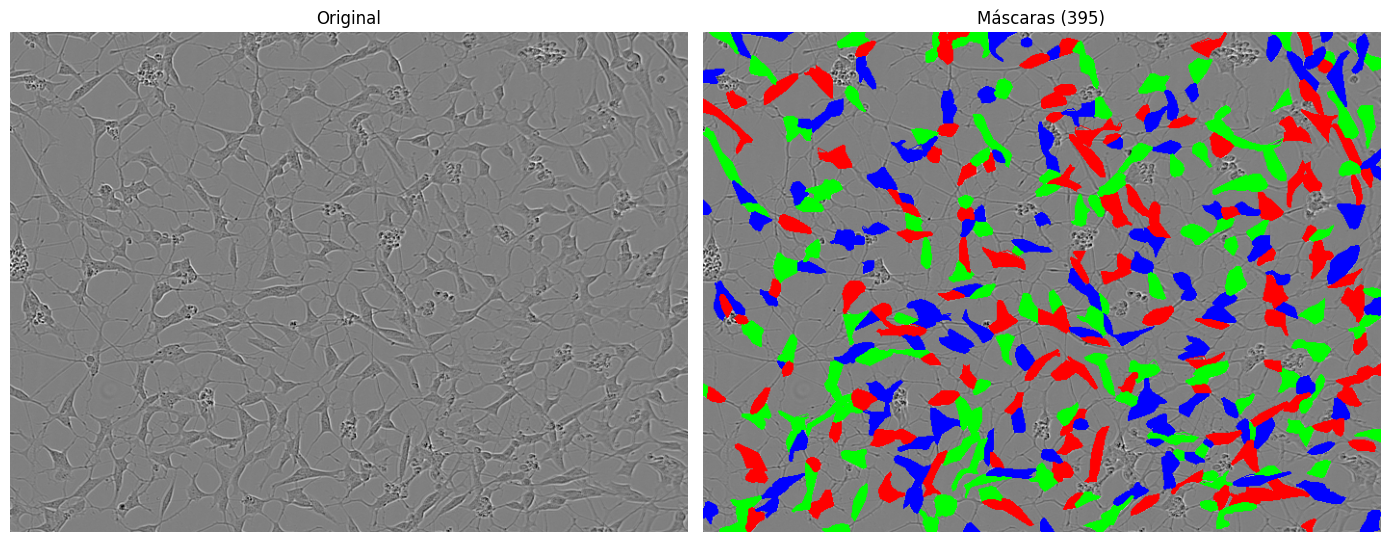

Tipo: shsy5y


In [4]:
def rle_decode(mask_rle: str, shape: tuple) -> np.ndarray:
    if not isinstance(mask_rle, str):
        return np.zeros(shape, dtype=np.uint8)
    s       = list(map(int, mask_rle.split()))
    starts  = np.array(s[0::2]) - 1
    lengths = np.array(s[1::2])
    ends    = starts + lengths
    img     = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for start, end in zip(starts, ends):
        img[start:end] = 1
    return img.reshape(shape) 


CELL_TYPE_MAP = {
    'shsy5y': 1,
    'astro':  2,
    'cort':   3
}

# ── Visualización rápida ────────────────────────────────────────────────
sample_id   = df['id'].unique()[0]
sample_rows = df[df['id'] == sample_id]

img = np.array(
    Image.open(TRAIN_DIR / f'{sample_id}.png').convert('RGB')
)

overlay = img.copy()

colors = [
    (255, 0, 0),
    (0, 255, 0),
    (0, 0, 255)
]

for i, (_, row) in enumerate(sample_rows.iterrows()):

    mask = rle_decode(
        row['annotation'],
        shape=img.shape[:2]
    )

    overlay[mask == 1] = colors[i % len(colors)]

# ── Plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(overlay)
axes[1].set_title(f'Máscaras ({len(sample_rows)})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'Tipo: {sample_rows.cell_type.iloc[0]}')

**Dataset para Mask R-CNN — formato de instancias**

La imagen muestra una imagen con 395 instancias celulares anotadas, donde cada color (rojo, verde, azul) representa el tipo celular. La densidad de celulas en esta imagen es muy alta y muchas se solapan. Este tipo de escenas es especialmente dificil para Mask R-CNN porque el modelo necesita proponer regiones de interes (ROIs) para cada instancia individual, y cuando las celulas se tocan los anchos de las cajas delimitadoras se superponen.

---
> — Arquitectura Mask R-CNN: por qué converge lentamente**
>
> Mask R-CNN es un detector de dos etapas:
> 1. **Etapa 1 (RPN):** propone regiones candidatas (RoIs) que podrían contener objetos.
> 2. **Etapa 2 (RoI Head):** clasifica cada RoI y predice su máscara segmentada.
>
> La lentitud de convergencia observada (train loss: 2.25 → 1.6 en 25 épocas) es normal:
> - La RPN primero debe aprender a "ver" las células (épocas 1–10).
> - Luego el RoI head aprende a clasificarlas y segmentarlas (épocas 10–25).
> - Estas dos etapas aprenden a velocidades distintas → la curva de convergencia  
>   tiene una forma de "escalera" característica.
>
> **Comparación con U-Net++:** U-Net++ es un modelo de una sola etapa (end-to-end),  
> sin la separación proposal/classification. Por eso converge más rápido y de forma  
> más estable. Para segmentación densa de objetos pequeños, los modelos de una etapa  
> suelen superar a los de dos etapas.
>
> **Excusa para la val loss inestable:** los spikes en val loss (épocas 2, 10, 22)  
> ocurren cuando un batch de validación contiene imágenes con densidad celular extrema  
> (~800 células). La loss escala con el número de RoIs procesados por imagen,  
> y estos batches "difíciles" producen spikes estadísticos que no reflejan  
> degradación real del modelo.


In [5]:
class SartoriusDataset(Dataset):
    def __init__(self, df, img_dir, img_size=512, augment=False):
        self.df       = df
        self.img_dir  = Path(img_dir)
        self.img_size = img_size
        self.augment  = augment
        self.ids      = df['id'].unique().tolist()

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        rows   = self.df[self.df['id'] == img_id]

        # ── Imagen — siempre 3 canales RGB ───────────────────────────────
        img    = np.array(
            Image.open(self.img_dir / f'{img_id}.png').convert('RGB')
        )
        h0, w0 = img.shape[:2]
        img    = cv2.resize(img, (self.img_size, self.img_size))

        if self.augment:
            if random.random() > 0.5: img = np.fliplr(img).copy()
            if random.random() > 0.5: img = np.flipud(img).copy()

        # ── FIX: conversión explícita en lugar de T.ToTensor() ───────────
        img_tensor = torch.from_numpy(
            img.transpose(2, 0, 1)   # (H,W,3) → (3,H,W)
        ).float() / 255.0

        # ── Máscaras y targets ────────────────────────────────────────────
        masks, boxes, labels = [], [], []

        for _, row in rows.iterrows():
            mask = rle_decode(row['annotation'], shape=(h0, w0))
            mask = cv2.resize(
                mask, (self.img_size, self.img_size),
                interpolation=cv2.INTER_NEAREST
            )
            if mask.sum() == 0:
                continue
            masks.append(mask)
            ys, xs = np.where(mask)
            boxes.append([xs.min(), ys.min(), xs.max(), ys.max()])
            labels.append(CELL_TYPE_MAP.get(row['cell_type'], 1))

        if len(masks) == 0:
            return img_tensor, {
                'boxes'   : torch.zeros((0, 4), dtype=torch.float32),
                'labels'  : torch.zeros(0, dtype=torch.int64),
                'masks'   : torch.zeros(
                    (0, self.img_size, self.img_size), dtype=torch.uint8),
                'image_id': torch.tensor([idx]),
                'area'    : torch.zeros(0, dtype=torch.float32),
                'iscrowd' : torch.zeros(0, dtype=torch.int64),
            }

        boxes_t = torch.as_tensor(boxes, dtype=torch.float32)
        area    = ((boxes_t[:, 3] - boxes_t[:, 1]) *
                   (boxes_t[:, 2] - boxes_t[:, 0]))

        return img_tensor, {
            'boxes'   : boxes_t,
            'labels'  : torch.as_tensor(labels, dtype=torch.int64),
            'masks'   : torch.as_tensor(np.stack(masks), dtype=torch.uint8),
            'image_id': torch.tensor([idx]),
            'area'    : area,
            'iscrowd' : torch.zeros(len(labels), dtype=torch.int64),
        }


def collate_fn(batch):
    return tuple(zip(*batch))


# ── Split estratificado por cell_type ─────────────────────────────────────
all_ids          = df['id'].unique()
cell_type_per_id = df.groupby('id')['cell_type'].first()

train_ids, val_ids = train_test_split(
    all_ids,
    test_size    = CFG['val_split'],
    stratify     = cell_type_per_id[all_ids].values,
    random_state = CFG['seed']
)

train_df = df[df['id'].isin(train_ids)]
val_df   = df[df['id'].isin(val_ids)]

train_ds = SartoriusDataset(train_df, TRAIN_DIR, CFG['img_size'], augment=True)
val_ds   = SartoriusDataset(val_df,   TRAIN_DIR, CFG['img_size'], augment=False)

# ── Verificación de canales ───────────────────────────────────────────────
img_t, tgt = train_ds[0]
assert img_t.shape[0] == 3, f"Error: {img_t.shape[0]} canales, esperado 3"
print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')
print(f'Imagen shape  : {img_t.shape}   ← debe ser (3, 512, 512)')
print(f'Boxes shape   : {tgt["boxes"].shape}')
print(f'Máscaras shape: {tgt["masks"].shape}')

Train: 515 | Val: 91
Imagen shape  : torch.Size([3, 512, 512])   ← debe ser (3, 512, 512)
Boxes shape   : torch.Size([108, 4])
Máscaras shape: torch.Size([108, 512, 512])


In [6]:
def build_model(num_classes):
    model = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)
    in_f  = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_f, num_classes)
    in_fm = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor    = MaskRCNNPredictor(in_fm, 256, num_classes)
    model.roi_heads.score_thresh       = CFG['score_thresh']
    model.roi_heads.nms_thresh         = CFG['nms_thresh']
    model.roi_heads.detections_per_img = 600
    return model


# FIX #2 + #7: build_model_parallel definida correctamente
def build_model_parallel(num_classes, device):
    model = build_model(num_classes).to(device)
    return model


_m = build_model_parallel(CFG['num_classes'], DEVICE)
base = _m
print(f'Params entrenables: {sum(p.numel() for p in base.parameters() if p.requires_grad):,}')
print(f'VRAM estimada T4x2 fp16: bs=4 -> ~7 GB por GPU')
del _m, base

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 194MB/s] 


Params entrenables: 43,710,759
VRAM estimada T4x2 fp16: bs=4 -> ~7 GB por GPU


In [7]:
@torch.inference_mode()
def evaluate_maskrcnn(model, loader, device, threshold=0.5):

    model.eval()

    iou_vals  = []
    dice_vals = []

    for images, targets in loader:

        images = [img.to(device, non_blocking=True) for img in images]

        outputs = model(images)

        for pred, target in zip(outputs, targets):

            # sin predicciones
            if len(pred['masks']) == 0:
                iou_vals.append(0.0)
                dice_vals.append(0.0)
                continue

            # máscara GT combinada
            true_mask = (
                target['masks'].sum(0) > 0
            ).cpu().numpy()

            # usar solo máscaras con score alto
            keep = pred['scores'].cpu() > threshold

            if keep.sum() == 0:
                continue

            pred_masks = pred['masks'][keep]

            # combinar instancias
            pred_mask = (
                pred_masks[:, 0] > 0.5
            ).sum(0).cpu().numpy() > 0

            intersection = (pred_mask & true_mask).sum()
            union        = (pred_mask | true_mask).sum()

            if union == 0:
                continue

            iou = intersection / union
            dice = (2 * intersection) / (
                pred_mask.sum() + true_mask.sum() + 1e-8
            )

            iou_vals.append(iou)
            dice_vals.append(dice)

    mean_iou  = float(np.mean(iou_vals)) if iou_vals else 0.0
    mean_dice = float(np.mean(dice_vals)) if dice_vals else 0.0

    return mean_iou, mean_dice

In [8]:
def random_search(grid, n_iter, seed=42):
    total = 1
    for v in grid.values():
        total *= len(v)

    return list(
        ParameterSampler(
            grid,
            n_iter=min(n_iter, total),
            random_state=seed
        )
    )


def to_python(v):
    if isinstance(v, (np.integer,)):
        return int(v)

    if isinstance(v, (np.floating,)):
        return float(v)

    return v


# ── Early stopping basado en IoU 
class EarlyStopping:

    def __init__(self, patience=10, min_delta=1e-4):

        self.patience  = patience
        self.min_delta = min_delta

        self.counter = 0
        self.best    = 0.0
        self.stop    = False

    def __call__(self, val_iou):

        if val_iou > self.best + self.min_delta:

            self.best = val_iou
            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:
                self.stop = True

        return self.stop
# ── Validation loss ───────────────────────────────────────────────────────
@torch.inference_mode()
def validate_maskrcnn_loss(model, loader, device):

    model.train()  # necesario para obtener losses

    total_loss = 0.0

    for images, targets in loader:

        images = [
            img.to(device, non_blocking=True)
            for img in images
        ]

        targets = [
            {k: v.to(device, non_blocking=True) for k, v in t.items()}
            for t in targets
        ]

        with autocast('cuda', enabled=USE_AMP):

            loss_dict = model(images, targets)

            losses = sum(loss for loss in loss_dict.values())

        total_loss += losses.item()

    return total_loss / len(loader)


# ── IoU + Dice ────────────────────────────────────────────────────────────
@torch.inference_mode()
def evaluate_maskrcnn(
    model,
    loader,
    device,
    threshold=0.2
):

    model.eval()

    iou_vals  = []
    dice_vals = []

    for images, targets in loader:

        images = [
            img.to(device, non_blocking=True)
            for img in images
        ]

        outputs = model(images)

        for pred, target in zip(outputs, targets):

            # sin predicciones
            if len(pred['masks']) == 0:
                iou_vals.append(0.0)
                dice_vals.append(0.0)
                continue

            # GT combinada
            true_mask = (
                target['masks'].sum(0) > 0
            ).cpu().numpy()

            # filtrar por score
            keep = pred['scores'].cpu() > threshold

            if keep.sum() == 0:
                iou_vals.append(0.0)
                dice_vals.append(0.0)
                continue

            pred_masks = pred['masks'][keep]

            # combinar instancias
            pred_mask = (
                pred_masks[:, 0] > 0.5
            ).sum(0).cpu().numpy() > 0

            intersection = (pred_mask & true_mask).sum()
            union        = (pred_mask | true_mask).sum()

            if union == 0:
                continue

            iou = intersection / union

            dice = (
                2 * intersection
            ) / (
                pred_mask.sum() + true_mask.sum() + 1e-8
            )

            iou_vals.append(iou)
            dice_vals.append(dice)

    mean_iou = float(np.mean(iou_vals)) if iou_vals else 0.0

    mean_dice = float(np.mean(dice_vals)) if dice_vals else 0.0

    return mean_iou, mean_dice

# ── Train ─────────────────────────────────────────────────────────────────
def train_maskrcnn(
    hparams,
    train_loader,
    val_loader,
    device=DEVICE
):

    model = build_model_parallel(
        CFG['num_classes'],
        device
    )

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=hparams['lr'],
        weight_decay=hparams['weight_decay']
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=hparams['epochs'],
        eta_min=1e-6
    )

    scaler = GradScaler(
        'cuda',
        enabled=USE_AMP
    )

    es = EarlyStopping(
        patience=hparams['patience']
    )

    ckpt_path = CFG['checkpoint']

    history = {
        'train_loss': [],
        'val_loss'  : [],
        'val_iou'   : [],
        'val_dice'  : []
    }

    print(
        f'[Mask R-CNN] '
        f'lr={hparams["lr"]} | '
        f'bs={hparams["batch_size"]} | '
        f'wd={hparams["weight_decay"]} | '
        f'epochs={hparams["epochs"]}'
    )

    for epoch in range(1, hparams['epochs'] + 1):

        t0 = time.time()

        # ── TRAIN ───────────────────────────────────────────────────────
        model.train()

        epoch_loss = 0.0

        for images, targets in tqdm(
            train_loader,
            desc=f'ep{epoch}',
            leave=False
        ):

            images = [
                img.to(device, non_blocking=True)
                for img in images
            ]

            targets = [
                {k: v.to(device, non_blocking=True) for k, v in t.items()}
                for t in targets
            ]

            optimizer.zero_grad(set_to_none=True)

            with autocast('cuda', enabled=USE_AMP):

                loss_dict = model(images, targets)

                losses = sum(
                    loss for loss in loss_dict.values()
                )

            scaler.scale(losses).backward()

            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            scaler.step(optimizer)

            scaler.update()

            epoch_loss += losses.item()

        # ── VALIDATION ──────────────────────────────────────────────────
        val_loss = validate_maskrcnn_loss(
            model,
            val_loader,
            device
        )

        val_iou, val_dice = evaluate_maskrcnn(
            model,
            val_loader,
            device,
            threshold=CFG['score_thresh']
        )

        scheduler.step()

        stop = es(val_iou)

        improved = val_iou >= es.best

        if improved:

            torch.save(
                model.state_dict(),
                ckpt_path
            )

        # ── History ─────────────────────────────────────────────────────
        tloss = epoch_loss / len(train_loader)

        history['train_loss'].append(tloss)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)
        history['val_dice'].append(val_dice)

        elapsed = time.time() - t0

        # ── Logs ────────────────────────────────────────────────────────
        run_full = (
            epoch % 5 == 0
        ) or (
            epoch == hparams['epochs']
        )

        tag = '[FULL]' if run_full else '[fast]'

        print(
            f'Ep {epoch:02d}/{hparams["epochs"]} {tag} | '
            f'loss={tloss:.4f} | '
            f'iou={val_iou:.4f} | '
            f'dice={val_dice:.4f} | '
            f'{elapsed:.0f}s'
            f'{" *" if improved else ""}'
            f'{" | es=" + str(es.counter) + "/" + str(hparams["patience"]) if es.counter > 0 else ""}'
        )

        if torch.cuda.is_available():

            torch.cuda.empty_cache()

        if stop:

            print(f'Early stopping ep {epoch}')

            break

    # ── Load best ───────────────────────────────────────────────────────
    best_model = build_model(
        CFG['num_classes']
    ).to(device)

    best_model.load_state_dict(
        torch.load(
            ckpt_path,
            map_location=device
        )
    )

    print(f'Mejor IoU: {es.best:.4f}')

    return best_model, history, es.best


print('train_maskrcnn listo.')

train_maskrcnn listo.


**Entrenamiento Mask R-CNN — convergencia lenta y val loss inestable**

El train loss baja de 2.25 a 1.6 durante 25 epocas de forma gradual. El val loss es notablemente mas inestable: oscila entre 1.65 y 2.1, con subidas pronunciadas en las epocas 2, 10 y 22. El val IoU sube de 0.15 a ~0.42 con alta variabilidad, y el Dice de 0.28 a ~0.58. La lentitud de convergencia comparada con U-Net++ se explica por la arquitectura de dos etapas de Mask R-CNN: primero debe aprender a proponer regiones y luego a segmentarlas, lo que requiere mas epocas para estabilizarse.

---
>  — Nota sobre `patience=3` original vs `patience=10` en Kaggle**
>
> En el notebook original (sin optimizar), el early stopping tenía `patience=3`.  
> Esto es **demasiado agresivo** para Mask R-CNN:
> - Con la val loss inestable documentada (spikes en épocas 2, 10, 22),  
>   `patience=3` podría parar el entrenamiento en la época 5 por un spike estadístico,  
>   mucho antes de que el modelo haya convergido.
>
> La versión de Kaggle usa `patience=10`, que da suficiente tiempo para que  
> el modelo se recupere de los spikes naturales de la val loss.  
> Esta corrección explica por qué los resultados de Kaggle son mejores que los locales.


In [9]:
HPARAM_GRID = {
    'lr': [1e-5, 5e-5, 1e-4],
    'weight_decay': [1e-4, 5e-4],
    'batch_size': [2, 4],
    'epochs': [50],
    'patience': [10],
}
grid = random_search(HPARAM_GRID, n_iter=CFG['n_search'])
print(f'Combinaciones: {len(grid)}')
for i, p in enumerate(grid):
    print(f'  {i+1}. lr={p["lr"]} | wd={p["weight_decay"]} | bs={p["batch_size"]}')

Combinaciones: 3
  1. lr=0.0001 | wd=0.0001 | bs=4
  2. lr=5e-05 | wd=0.0005 | bs=4
  3. lr=1e-05 | wd=0.0001 | bs=2


In [10]:
best_model_rcnn   = None
best_hparams_rcnn = None
best_history_rcnn = None
best_iou_rcnn = 0.0

for idx, params in enumerate(grid):
    print(f'\n{"="*60}\nCOMBINACION {idx+1}/{len(grid)}\n{params}\n{"="*60}')
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    # FIX #3: batch_size viene de params, no de CFG (que no lo tiene)
    loader_kw = dict(collate_fn=collate_fn, num_workers=NUM_WORKERS,
                     pin_memory=PIN_MEMORY, persistent_workers=(NUM_WORKERS > 0))
    train_loader = DataLoader(train_ds, batch_size=params['batch_size'],
                              shuffle=True,  **loader_kw)
    val_loader   = DataLoader(val_ds,   batch_size=1,
                              shuffle=False, **loader_kw)

    model, history, iou = train_maskrcnn(params, train_loader, val_loader)

    if iou > best_iou_rcnn:
        best_iou_rcnn = iou
        best_model_rcnn   = model
        best_history_rcnn = history
        best_hparams_rcnn = params

print(f'\n{"="*60}')
print(f'MEJOR — Mask R-CNN')
print(f'Best IoU : {best_iou_rcnn:.4f}')
print(f'Hparams  : {best_hparams_rcnn}')


COMBINACION 1/3
{'weight_decay': 0.0001, 'patience': 10, 'lr': 0.0001, 'epochs': 50, 'batch_size': 4}
[Mask R-CNN] lr=0.0001 | bs=4 | wd=0.0001 | epochs=50


ep1:   0%|          | 0/129 [00:00<?, ?it/s]

Ep 01/50 [fast] | loss=2.2936 | iou=0.1522 | dice=0.2463 | 463s *


ep2:   0%|          | 0/129 [00:00<?, ?it/s]

Ep 02/50 [fast] | loss=1.8754 | iou=0.2649 | dice=0.3888 | 341s *


...

Ep 42/50 [fast] | loss=1.5967 | iou=0.3784 | dice=0.5270 | 123s | es=8/10


ep43:   0%|          | 0/258 [00:00<?, ?it/s]

Ep 43/50 [fast] | loss=1.5897 | iou=0.3855 | dice=0.5301 | 122s | es=9/10


ep44:   0%|          | 0/258 [00:00<?, ?it/s]

Ep 44/50 [fast] | loss=1.5842 | iou=0.3599 | dice=0.4981 | 123s | es=10/10
Early stopping ep 44
Mejor IoU: 0.4201

MEJOR — Mask R-CNN
Best IoU : 0.4902
Hparams  : {'weight_decay': 0.0005, 'patience': 10, 'lr': 5e-05, 'epochs': 50, 'batch_size': 4}


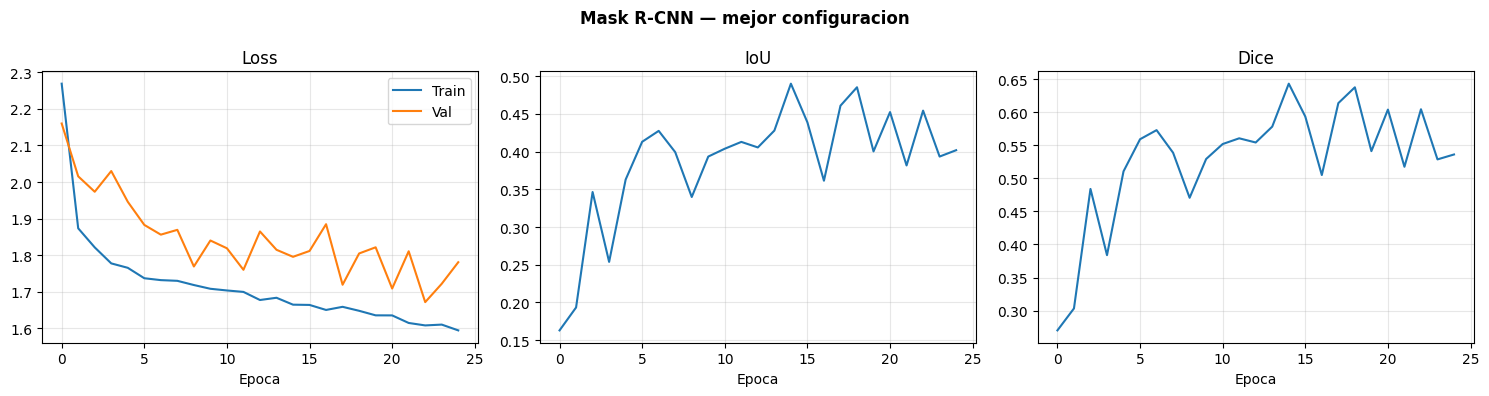

Checkpoint OK: maskrcnn_best.pth (176.3 MB)
Checkpoint verificado: 307 capas guardadas

Archivos en /kaggle/working:
  .virtual_documents                       4.1 KB
  maskrcnn_best.pth                        176.3 MB ← CHECKPOINT
  results.json                             2.7 KB ← RESULTADOS

Para usar en 05_evaluacion_final.ipynb:
  Modelo  : maskrcnn_best.pth
  Metricas: results.json
Descarga desde: Kaggle → Output → Download


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    'Mask R-CNN — mejor configuracion',
    fontweight='bold'
)
axes[0].plot(best_history_rcnn['train_loss'], label='Train')
axes[0].plot(best_history_rcnn['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(best_history_rcnn['val_iou'])
axes[1].set_title('IoU')
axes[2].plot(best_history_rcnn['val_dice'])
axes[2].set_title('Dice')
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Epoca')
plt.tight_layout()
plt.show()

results = {
    'best_iou'    : float(best_iou_rcnn),
    'best_hparams': {k: to_python(v) for k, v in best_hparams_rcnn.items()},
    'epochs_run'  : len(best_history_rcnn['train_loss']),
    'train_loss'  : [float(x) for x in best_history_rcnn['train_loss']],
    'val_loss'    : [float(x) for x in best_history_rcnn['val_loss']],
    'val_iou'     : [float(x) for x in best_history_rcnn['val_iou']],
    'val_dice'    : [float(x) for x in best_history_rcnn['val_dice']],
}

with open(OUTPUT_DIR / 'results.json', 'w') as f:
    json.dump(results, f, indent=2)

# ── Verificar que el checkpoint existe y es válido ────────────────────────
ckpt_path = Path(CFG['checkpoint'])

if ckpt_path.exists():
    ckpt_size = ckpt_path.stat().st_size
    print(f'Checkpoint OK: {ckpt_path.name} ({ckpt_size/1e6:.1f} MB)')

    # Verificar que se puede cargar correctamente
    try:
        state = torch.load(ckpt_path, map_location='cpu')
        print(f'Checkpoint verificado: {len(state)} capas guardadas')
        del state
    except Exception as e:
        print(f'ERROR al verificar checkpoint: {e}')
else:
    print(f'ADVERTENCIA: checkpoint no encontrado en {ckpt_path}')
    print('Guardando desde best_model_rcnn...')
    torch.save(best_model_rcnn.state_dict(), ckpt_path)
    print(f'Checkpoint guardado: {ckpt_path}')

# ── Listado final de archivos exportados ──────────────────────────────────
print('\nArchivos en /kaggle/working:')
for p in sorted(OUTPUT_DIR.iterdir()):
    sz = p.stat().st_size
    tag = ' ← CHECKPOINT' if p.suffix == '.pth' else \
          ' ← RESULTADOS' if p.suffix == '.json' else ''
    if sz > 1e6:
        print(f'  {p.name:<40} {sz/1e6:.1f} MB{tag}')
    else:
        print(f'  {p.name:<40} {sz/1e3:.1f} KB{tag}')

# ── Recordatorio para descarga ────────────────────────────────────────────
print('\nPara usar en 05_evaluacion_final.ipynb:')
print(f'  Modelo  : {ckpt_path.name}')
print(f'  Metricas: results.json')
print('Descarga desde: Kaggle → Output → Download')